In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import gzip

# import html
# import itertools
# import os
import pickle
from pathlib import Path

# import graphviz
# import imageio
import matplotlib as mpl
import matplotlib.pyplot as plt

# import networkx as nx
import numpy as np
import pandas as pd

# import pydot
import seaborn as sns
from browsergym.workarena.tasks.compositional.utils.curriculum import AGENT_CURRICULUM

# from PIL import Image
from agentlab.analyze import inspect_results

sns.set_context("notebook") # makes the text in the plots larger, for better visibility
%config InlineBackend.figure_format = 'svg' # makes the plots HD in the notebook
mpl.rcParams["figure.autolayout"] = True # enables tigh layout. Better multiplots
plt.rcParams['font.family'] = 'sans-serif'

/Users/montis/workspace/workarena_hackathon/AgentLab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Constants

In [3]:
TASK_NAME_PREFIX ="workarena.servicenow."
TASK_NAME_SUFFIX = "-l2"
PREFIX_OFFSET = len(TASK_NAME_PREFIX)
SUFFIX_OFFSET = len(TASK_NAME_SUFFIX)
TECHNIQUE = "hpa"
PKL_PREFIX = "step_"
PKL_SUFFIX = ".pkl.gz"
PKL_PATTERN = f"{PKL_PREFIX}*{PKL_SUFFIX}"

# DATA_PATHS = [
#    Path("/Users/montis/agentlab_results/2026-03-12_10-54-28_genericagent-google-gemini-3-flash-preview-on-workarena-l2-agent-curriculum-eval-400")
# ] # Paths to the data.

hpa_path = Path("/Users/montis/agentlab_results/2026-03-16_09-27-49_hpaagent-google-gemini-3-flash-preview-on-workarena-l2-agent-curriculum-eval-451")
baseline_path = Path("/Users/montis/agentlab_results/2026-03-12_10-54-28_genericagent-google-gemini-3-flash-preview-on-workarena-l2-agent-curriculum-eval-400")


# Processing

In [ ]:
def read_raw_data_and_reset_index(data_path: str) -> pd.DataFrame:
    df = inspect_results.load_result_df(data_path)
    df = df.reset_index()
    return df

def compute_accuracy(df: pd.DataFrame) -> float:
    return df["cum_reward"].mean() * 100

def get_agent_name_with_accuracy(df: pd.DataFrame) -> str:
    base_agent_name = df["agent.agent_name"].iloc[0]
    accuracy_str = str(compute_accuracy(df).round(1))
    return f"{base_agent_name}_{accuracy_str}"

def add_tree_evolution_to_dataframe(df: pd.DataFrame) -> list[dict]:
    tree_evolution_list = []
    for _, row in df.iterrows():
        exp_dir = Path(row["exp_dir"])
        pkl_file_list = list(exp_dir.glob(PKL_PATTERN))
        pkl_file_list.sort(key=lambda x: int(Path(x.stem).stem.split("_")[-1]))
        tree_evolution = {}
        for index, pkl_file in enumerate(pkl_file_list):
            with gzip.open(pkl_file, "rb") as f:
                obj = pickle.load(f)
                if hasattr(obj.agent_info, "extra_info"):
                    tree_evolution[f"{PKL_PREFIX}{index}"] = obj.agent_info.extra_info["hpa_plan"]
        tree_evolution_list.append(tree_evolution)
    return tree_evolution_list

def count_retries(tree_evolution: dict) -> int:
    """
    Computes the maximum retry value encountered during the tree evolution.
    """
    max_retry = 0

    for step in tree_evolution.values():
        # Access the list of expansion attempts in this step
        expansions = step.get("expansions", [])
        
        for entry in expansions:
            # Update max_retry if the current 'retry' value is higher
            current_retry = entry.get("retry", 0)
            if current_retry > max_retry:
                max_retry = current_retry
                
    return max_retry

def preprocess_raw_data(df: pd.DataFrame, is_genericagent: bool = False, save_csv: bool = False) -> pd.DataFrame:
    preprocessed_df = df.copy()
    agent_name_with_accuracy = get_agent_name_with_accuracy(preprocessed_df)
    task_lookup = {task.__name__.lower(): key for key in AGENT_CURRICULUM.keys() for bucket in AGENT_CURRICULUM[key]["buckets"] for task in bucket}
    preprocessed_df["env.task_name"] = [task_name[PREFIX_OFFSET:-SUFFIX_OFFSET] for task_name in preprocessed_df["env.task_name"]]
    preprocessed_df["model"] = [agent_name_with_accuracy] * len(preprocessed_df)
    preprocessed_df["task_category"] = preprocessed_df["env.task_name"].map(lambda x: task_lookup.get("".join(x.split("-")) + "task", "unknown"))
    if not is_genericagent:
        preprocessed_df["tree_evolution"] = add_tree_evolution_to_dataframe(preprocessed_df)
        preprocessed_df["pruned_nodes"] = preprocessed_df["tree_evolution"].apply(
            lambda x: sum(len(step["tree_update"]["prune"]) for step in x.values())
        )
        preprocessed_df["task_retries"] = preprocessed_df["tree_evolution"].apply(count_retries)
    if save_csv:
        preprocessed_df.to_csv(f"preprocessed_l2_{agent_name_with_accuracy}.csv")
    return preprocessed_df

def str_to_dict(s):
    return eval(s)

def read_preprocessed_csv(path: Path) -> pd.DataFrame:
    preprocessed_df = pd.read_csv(path)
    preprocessed_df["tree_evolution"] = preprocessed_df["tree_evolution"].apply(str_to_dict)
    return preprocessed_df

def aggregate_by_task_name_and_compute_statistics(df: pd.DataFrame, is_genericagent: bool = False) -> pd.DataFrame:
    """
    Compute the statistics grouping the databy task name
    """
    if not is_genericagent:
        aggregated_df = df.groupby(["task_category", "model"]).agg(
            avg_cum_reward=("cum_reward", "mean"),
            avg_n_steps=("n_steps", "mean"),
            median_pruned=("pruned_nodes", "median"),
            avg_task_retries=("task_retries", "mean"),
        ).reset_index()
    else:
        aggregated_df = df.groupby(["task_category", "model"]).agg(
            avg_cum_reward=("cum_reward", "mean"),
            avg_n_steps=("n_steps", "mean"),
        ).reset_index()
    return aggregated_df

def compute_relative_aggregated_statistics(aggregated_df: pd.DataFrame, aggregated_baseline_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute the statistics relative to the baseline and aggregated by task name
    """
    aggregated_df = aggregated_df.sort_values(by="task_category")
    aggregated_baseline_df = aggregated_baseline_df.sort_values(by="task_category")
    aggregated_df["relative_cum_reward"] = (aggregated_df["avg_cum_reward"] - aggregated_baseline_df["avg_cum_reward"]) / aggregated_baseline_df["avg_cum_reward"] * 100
    aggregated_df["relative_n_steps"] = (aggregated_df["avg_n_steps"] - aggregated_baseline_df["avg_n_steps"]) / aggregated_baseline_df["avg_n_steps"] * 100
    return aggregated_df

# def filter_and_sort_by_median_pruned(df: pd.DataFrame, median_threshold: int = 0) -> pd.DataFrame:
#     """
#     Filter and sort the dataframe by the median number of pruned nodes using a threshold
#     """
#     filtered_df = df[df["median_pruned"] > median_threshold]
#     return filtered_df.sort_values("median_pruned")

# def prepare_oracle_data(df: pd.DataFrame):
#     oracle_df = df.rename(columns={"category": "task_category", "task_name": "env.task_name", "avg_n_actions": "avg_n_steps", "std_n_actions": "std_n_steps"})
#     oracle_df["model"] = ["Oracle"] * len(oracle_df)
#     high_bounds = oracle_df.copy()
#     high_bounds['n_steps'] = oracle_df['avg_n_steps'] + oracle_df['std_n_steps']
    
#     low_bounds = oracle_df.copy()
#     low_bounds['n_steps'] = oracle_df['avg_n_steps'] - oracle_df['std_n_steps']

#     combined_oracle_df = pd.concat([high_bounds, low_bounds]).reset_index(drop=True)
#     return combined_oracle_df

# Visualization

In [ ]:
def plot_combined_reward_step_count(df: pd.DataFrame, save: bool = False):
    # 1. Increase figsize height to accommodate thicker bars
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
    sorted_df = df.sort_values(by=["model", "cum_reward"], ascending=[False, True])

    # Plotting parameters
    # width: total space used by the group (0.8 is standard, 0.9 is chunky)
    # gap: space between the bars within the group (0.1 - 0.2 is usually ideal)
    plot_params = {
        "data": sorted_df,
        "y": "task_category",
        "hue": "model",
        "orient": 'h',
        "errorbar": None,
        "width": 0.6,    
    }

    # Left Plot: Average Reward
    sns.barplot(ax=ax1, x="cum_reward", **plot_params)
    ax1.set_xlabel("Average Reward")
    ax1.set_ylabel("Task Category")
    ax1.grid(True, axis="x", linestyle="--", alpha=0.6)
    ax1.set_xlim(0, 1)

    # Right Plot: Average Step Count
    sns.barplot(ax=ax2, x="n_steps", **plot_params)
    ax2.set_xlabel("Average Step Count")
    ax2.set_ylabel("") 
    ax2.grid(True, axis="x", linestyle="--", alpha=0.6)
    ax2.set_xlim(0, 51)

    # Legend & Layout
    handles, labels = ax1.get_legend_handles_labels()
    ax1.get_legend().remove()
    ax2.get_legend().remove()
    fig.legend(handles, labels, loc='upper center', title="Model", 
               bbox_to_anchor=(0.5, 0.98), ncol=len(labels))

    # Optional: Increase space between the subplots
    plt.subplots_adjust(wspace=0.15) 
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    if save:
        models_str = '_'.join(df.model.unique())
        plt.savefig(f"plots/l2_combined_metrics_{models_str}.png", bbox_inches="tight", dpi=200)
    
    plt.show()

def visualize_retried_tasks(df: pd.DataFrame, save: bool = False) -> None:
    # Select only the rows of the dataframe where task_retries is greater than 0
    retried_tasks_df = df[df["task_retries"] > 0].copy()
    # Sort task names in ascending order by the median of the cumulative rewards
    task_rank = (
        retried_tasks_df.groupby("task_category")["cum_reward"]
        .sum()
        .sort_values(ascending=True)
        .index
    )
    retried_tasks_df["task_category"] = pd.Categorical(
        retried_tasks_df["task_category"], categories=task_rank, ordered=True
    )
    # Plot the histogram
    color_map = {0.0: "red", 1.0: "green"}
    plt.figure(figsize=(10, 6))
    g = sns.histplot(
        data=retried_tasks_df,
        y="task_category",
        hue="cum_reward",
        multiple="stack",
        discrete=True,
        shrink=0.8,
        palette=color_map,
    )

    g.set_xlabel("Retried Tasks Count")
    g.set_ylabel("Task Category")
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1), title="Reward")
    g.grid(axis="x", linestyle="--", alpha=0.5, linewidth=0.8)
    # tab10_blue = sns.color_palette("tab10")[0]
    # tab10_orange = sns.color_palette("tab10")[1]
    # tab10_green = sns.color_palette("tab10")[2]
    # tab10_red = sns.color_palette("tab10")[3]
    # tab10_purple = sns.color_palette("tab10")[4]
    # plt.axvline(x=56, linestyle="--", color=tab10_green, linewidth=1)
    # plt.axvline(x=55, linestyle="--", color=tab10_red, linewidth=1)
    # plt.axvline(x=48, linestyle="--", color=tab10_purple, linewidth=1)
    # plt.axvline(x=44, linestyle="--", color=tab10_blue, linewidth=1)
    # plt.axvline(x=32, linestyle="--", color=tab10_orange, linewidth=1)

    if save:
        plt.savefig(Path(f"plots/l2_retried_tasks_histogram_{df['model'].iloc[0]}.png"), bbox_inches="tight", dpi=200)

    plt.tight_layout()
    plt.show()


def visualize_pruned_tasks(df: pd.DataFrame, median_threshold: int = 0, save: bool = False) -> None:
    # Create a copy of the dataframe to avoid modifying the original one
    df_copy = df.copy()
    # Create a new column with the total number of pruned nodes for each row in the dataframe
    total_pruned_list = [
        sum(len(step["tree_update"]["prune"]) for step in row_val.values())
        for row_val in df_copy["tree_evolution"]
    ]
    df_copy["total_pruned"] = total_pruned_list
    # Filter the dataframe to only include tasks with a median number of pruned nodes greater than the threshold. Median is used for robustness against outliers.
    pruned_tasks_df = df_copy[
        df_copy.groupby("task_category")["total_pruned"].transform("median") > median_threshold
    ].copy()
    # Sort the tasks by the median number of pruned nodes in ascending order
    task_rank = (
        pruned_tasks_df.groupby("task_category")["total_pruned"]
        .median()
        .sort_values(ascending=True)
        .index
    )
    pruned_tasks_df["task_category"] = pd.Categorical(
        pruned_tasks_df["task_category"], categories=task_rank, ordered=True
    )
    # Plot the bar plot
    plt.figure(figsize=(8, 5))
    g = sns.barplot(
        pruned_tasks_df,
        y="task_category",
        x="total_pruned",
        estimator="median",
        color="#FFD700",
        capsize=0.2,
        err_kws={
            "linewidth": 0.8,
            "color": "black",
            "alpha": 0.8,
        },
    )
    g.set_xlabel("Median Pruned Nodes")
    g.set_ylabel("Task Category")
    g.grid(axis="x", linestyle="--", alpha=0.5, linewidth=0.8)
    
    if save:
        plt.savefig(Path(f"plots/l2_median_pruned_nodes_{df['model'].iloc[0]}.png"), bbox_inches="tight", dpi=200)

    plt.tight_layout()
    plt.show()

def plot_correlation(df: pd.DataFrame, is_genericagent: bool = False, relative_to_baseline: bool = False, save: bool = False):
    """Heatmap of metric correlations with improved label formatting."""
    plt.figure(figsize=(8, 6))
    
    # Logic for selecting columns
    if is_genericagent:
        cols = ['avg_cum_reward', 'avg_n_steps']
    elif not relative_to_baseline:
        cols = ['avg_cum_reward', 'avg_n_steps', 'median_pruned', 'avg_task_retries']
    else:
        # cols = ['relative_cum_reward', 'relative_n_steps', 'median_pruned', 'avg_task_retries']
        cols = ['relative_cum_reward', 'relative_remaining_steps', 'median_pruned', 'avg_task_retries']
    
    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    # 1. Clean labels: replace '_' with ' ' and capitalize
    clean_labels = [col.replace('_', ' ').title() for col in cols]

    # 2. Add 'cbar_kws' to name the color bar
    ax = sns.heatmap(
        corr, 
        mask=mask,
        annot=True, 
        cmap='RdBu_r', 
        center=0, 
        vmin=-1, 
        vmax=1, 
        fmt='.2f', 
        square=True,
        xticklabels=clean_labels, 
        yticklabels=clean_labels,
        cbar_kws={'label': 'Correlation'}
    )

    # 3. Rotate x-axis labels
    plt.xticks(rotation=20, ha='right')
    plt.yticks(rotation=0)

    if save:
        plt.savefig(Path(f"plots/l2_{'relative' if relative_to_baseline else 'absolute'}_correlation_matrix_{df['model'].iloc[0]}.png"), bbox_inches="tight", dpi=200)

    plt.tight_layout()
    plt.show()

def plot_task_distribution(df: pd.DataFrame):
    tasks = []

    for unique_task in df["env.task_name"].unique():
        task = {}
        n_samples = len(df[df["env.task_name"] == unique_task])
        task["task_name"] = unique_task
        task["n_samples"] = n_samples
        tasks.append(task)

    tasks_df = pd.DataFrame(tasks)

    sns.histplot(data=tasks_df, x="n_samples", discrete=True)
    plt.xlabel("Number of Samples per Task")
    plt.ylabel("Number of Tasks")
    plt.grid(True, axis="y", linestyle="--", alpha=0.6, linewidth=0.8)
    plt.show()

# Run processing

In [6]:
raw_baseline = read_raw_data_and_reset_index(baseline_path)
raw_hpa = read_raw_data_and_reset_index(hpa_path)

Loading results: 100%|██████████| 235/235 [00:00<00:00, 1024.73it/s]


In [ ]:
preprocessed_baseline = preprocess_raw_data(df=raw_baseline, is_genericagent=True, save_csv=False)
# preprocessed_hpa = preprocess_raw_data(df=raw_hpa, is_genericagent=False, save_csv=False)
preprocessed_hpa_path = Path("preprocessed_l2_HPAAgent-google_gemini-3-flash-preview_45.1.csv")
preprocessed_hpa = read_preprocessed_csv(preprocessed_hpa_path)

In [8]:
preprocessed_concat = pd.concat([preprocessed_baseline, preprocessed_hpa]).reset_index(drop=True)

In [9]:
# preprocessed_baseline["task_category"].value_counts()
# preprocessed_baseline[["env.task_name", "env.task_seed", "cum_reward", "n_steps", "task_category"]]

In [9]:
aggregated_baseline = aggregate_by_task_name_and_compute_statistics(preprocessed_baseline, is_genericagent=True)
aggregated_hpa = aggregate_by_task_name_and_compute_statistics(preprocessed_hpa, is_genericagent=False)
aggregated_hpa = compute_relative_aggregated_statistics(aggregated_hpa, aggregated_baseline)

In [10]:
aggregated_baseline["avg_remaining_steps"] = ([50] * len(aggregated_baseline)) - aggregated_baseline["avg_n_steps"]
aggregated_hpa["avg_remaining_steps"] = ([50] * len(aggregated_hpa)) - aggregated_hpa["avg_n_steps"]
aggregated_hpa["relative_remaining_steps"] = (aggregated_hpa["avg_remaining_steps"] - aggregated_baseline["avg_remaining_steps"]) / aggregated_baseline["avg_remaining_steps"] * 100

# Run visualization

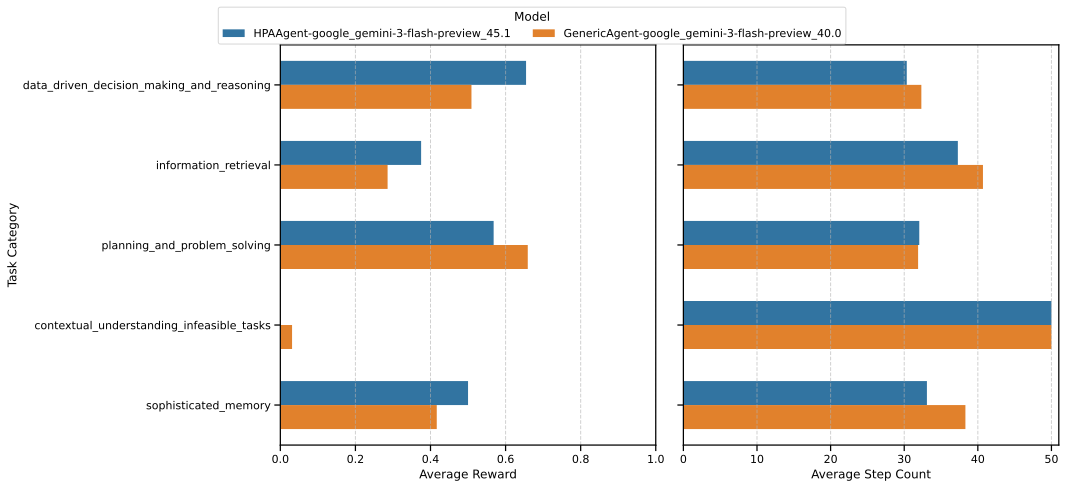

In [ ]:
plot_combined_reward_step_count(preprocessed_concat)

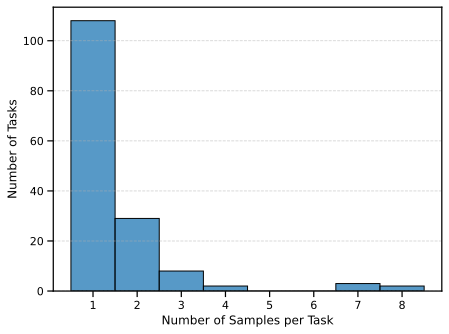

In [ ]:
plot_task_distribution(df=preprocessed_hpa)

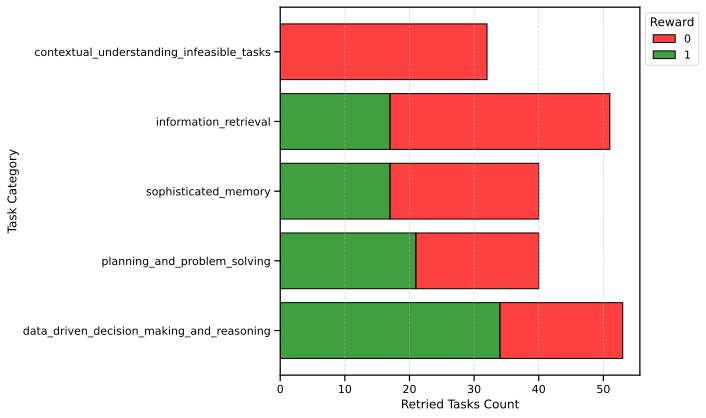

In [ ]:
visualize_retried_tasks(df=preprocessed_hpa)

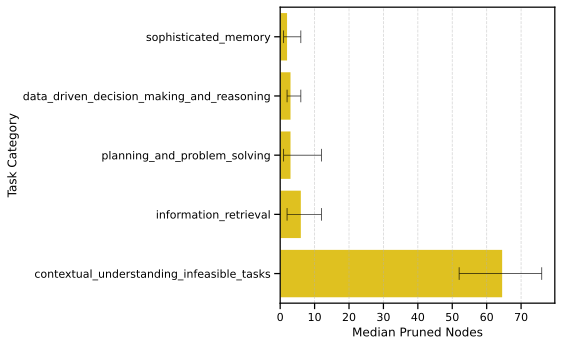

In [ ]:
visualize_pruned_tasks(df=preprocessed_hpa)

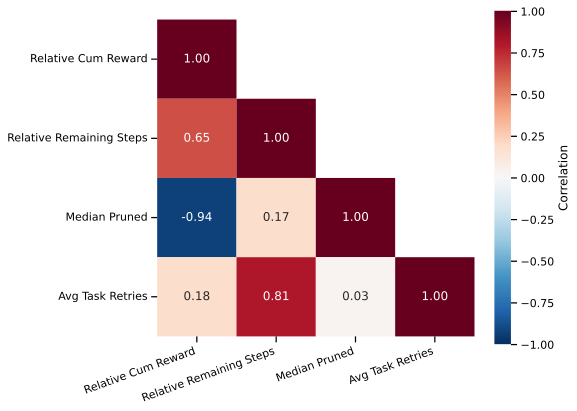

In [ ]:
plot_correlation(df=aggregated_hpa, is_genericagent=False, relative_to_baseline=True)